# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

Business framing:  

Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Load the hotel bookings dataset by [downloading the file](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-02-11/readme.md#get-the-data-here) or using this link: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [2]:
import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Display the first few rows
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


1. There are a large number of columns, so some of those might have to be dropped or transformed. Some columns like agent and company have missing data as well.

## 2. Select and Prepare Features

Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Choose numeric features related to customer behavior
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'total_of_special_requests']
df_clustering = df[features].copy()

# Drop rows with missing values in the selected features
df_clustering.dropna(inplace=True)

# Handle potential infinite values in adr
df_clustering = df_clustering.replace([np.inf, -np.inf], np.nan).dropna()


# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Display the first few rows of the scaled data
display(pd.DataFrame(df_scaled, columns=features).head())

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
0,2.227051,-0.92889,-1.310240,-2.015038,-0.720694
1,5.923385,-0.92889,-1.310240,-2.015038,-0.720694
2,-0.907814,-0.92889,-0.786207,-0.530935,-0.720694
3,-0.851667,-0.92889,-0.786207,-0.530935,-0.720694
4,-0.842309,-0.92889,-0.262174,-0.075810,0.540666


1. The features that I selected were lead_time for how far in advance the customer books, adr for reflecting the price sensetivity of customers, and stays_in_weekend_nights for the duration and type of stay.
2. Based on these features, I expect to find the last minute travelers, the travelers that plan ahead more, business travelers, and customers with specific needs.

## 3. Apply K-Means Clustering

Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



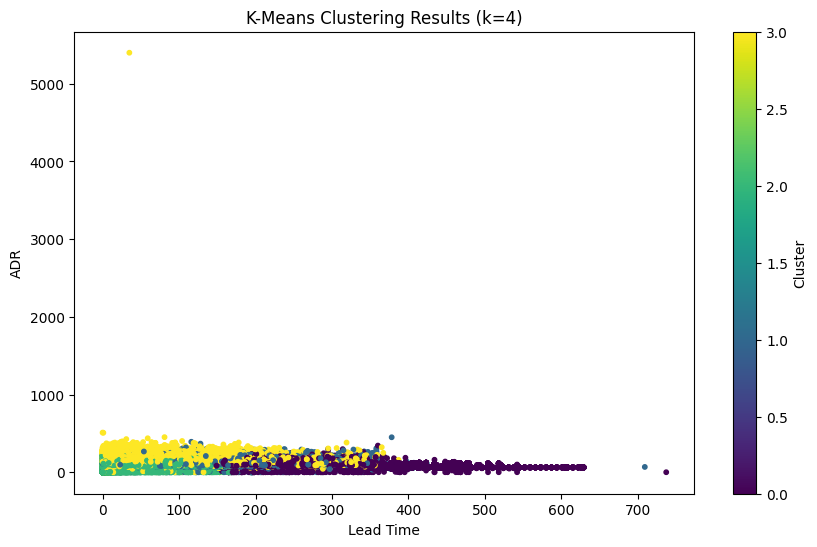

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Choose the number of clusters (k)
k = 4

# Fit the KMeans model
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
df_clustering['kmeans_cluster'] = kmeans.fit_predict(df_scaled)

# Visualize the clusters using a scatterplot of two features
plt.figure(figsize=(10, 6))
plt.scatter(df_clustering['lead_time'], df_clustering['adr'], c=df_clustering['kmeans_cluster'], cmap='viridis', marker='o', s=10)
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.title('K-Means Clustering Results (k=4)')
plt.colorbar(label='Cluster')
plt.show()

1. I chose a k value of 4, because it was right inbetween 3 and 5. Without evaluating further it is difficult to determine the optimal number of clusters.
2. The types of customers that showed up in the clusters were low budget travelers, people looking for deals, and average pricing with last-minute bookings.

## 4. Apply Gaussian Mixture Model (GMM)

Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


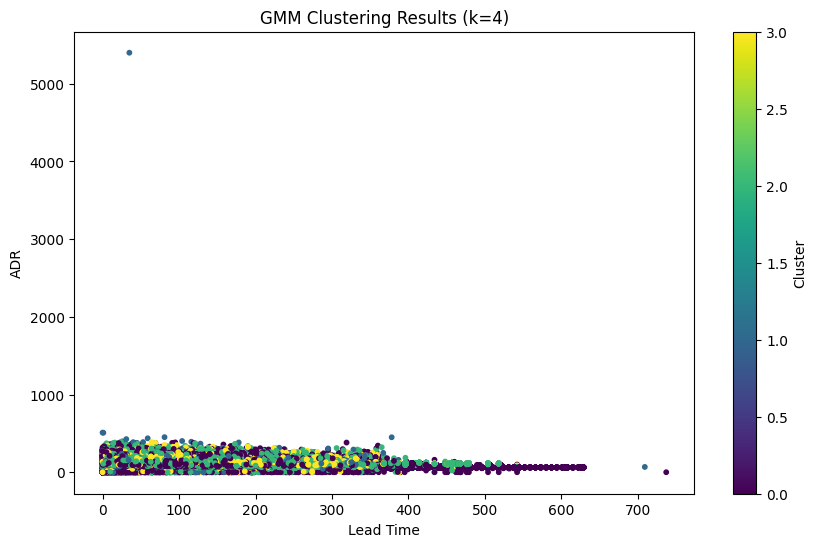

In [6]:
from sklearn.mixture import GaussianMixture

# Fit the GMM model with the same number of clusters as KMeans
gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(df_scaled)

# Predict the cluster probabilities (soft clustering)
cluster_probabilities = gmm.predict_proba(df_scaled)

# Predict the cluster labels (hard assignment based on highest probability) for visualization
gmm_clusters = gmm.predict(df_scaled)
df_clustering['gmm_cluster'] = gmm_clusters

# Visualize the GMM clusters using a scatterplot of two features
plt.figure(figsize=(10, 6))
plt.scatter(df_clustering['lead_time'], df_clustering['adr'], c=df_clustering['gmm_cluster'], cmap='viridis', marker='o', s=10)
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.title('GMM Clustering Results (k=4)')
plt.colorbar(label='Cluster')
plt.show()

1. Both Kmeans and GMM with k=4 showed similar groupings, but the boundaries were more soft in GMM and Kmeans had more distinct boundaries.
2. Some business questions that GMM might help answer better would be things like if a customer has characteristics of multiple segments, like if they are a business traveler and a casual traveler.

## 5. Evaluate Your Models

Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

- Calculate:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index
- Compare both models

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate WCSS for KMeans
# WCSS is the inertia for KMeans
kmeans_wcss = kmeans.inertia_
print(f"KMeans WCSS: {kmeans_wcss}")

# Calculate Silhouette Score for KMeans
kmeans_silhouette = silhouette_score(df_scaled, df_clustering['kmeans_cluster'])
print(f"KMeans Silhouette Score: {kmeans_silhouette}")

# Calculate Davies-Bouldin Index for KMeans
kmeans_davies_bouldin = davies_bouldin_score(df_scaled, df_clustering['kmeans_cluster'])
print(f"KMeans Davies-Bouldin Index: {kmeans_davies_bouldin}")

print("-" * 20)

# Calculate Silhouette Score for GMM
gmm_silhouette = silhouette_score(df_scaled, df_clustering['gmm_cluster'])
print(f"GMM Silhouette Score: {gmm_silhouette}")

# Calculate Davies-Bouldin Index for GMM
gmm_davies_bouldin = davies_bouldin_score(df_scaled, df_clustering['gmm_cluster'])
print(f"GMM Davies-Bouldin Index: {gmm_davies_bouldin}")

KMeans WCSS: 346243.9698577152
KMeans Silhouette Score: 0.23285164553914312
KMeans Davies-Bouldin Index: 1.4098123263286104
--------------------
GMM Silhouette Score: 0.12388534983967643
GMM Davies-Bouldin Index: 2.624348922677046


1. The Kmeans model performed better in creating more distinct clusters. This means that k=4 and the selected features are more defined with those metrics.
2. Kmeans would be the recommended model because of its simpler interpretation and cluster groupings. The better performance for clustering metrics means that it can generate better defined segments.

## 6. Business Interpretation

Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

- Review characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Think from a marketing or hotel operations perspective

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [11]:
# Calculate the mean of the features for each KMeans cluster
cluster_means = df_clustering.groupby('kmeans_cluster')[features].mean()

# Display the cluster means
display(cluster_means)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
kmeans_cluster,,,,,
0,272.176221,0.642105,2.200830,89.837767,0.195936
1,134.566089,2.388476,5.801003,101.491484,0.526366
2,45.504168,0.628329,1.755681,86.568845,0.226577
3,71.194670,0.903631,2.313683,140.829597,1.553604


The segments represent early planners, extended stay/leisure travelers, last-minute travelers, and higher-value demanding guests. The hotel could use targeted sales and promotions for each group in order to earn more revenue and business in general.

## 7. Final Reflection

Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


1. One of the most challenging aspects is evaluating the performance of the models and determining the optimal number of clusters without predefined labels. Interpreting the meaning of the resulting clusters in a business context also requires careful analysis and domain knowledge.

2. Clustering is used when you want to discover hidden patterns and group data points into meaningful segments without having a target variable or known labels. This is particularly useful for exploratory data analysis, customer segmentation, or anomaly detection where the categories are not predefined.

3. Clustering helps us automatically group our customers or data into distinct types based on their behavior or characteristics, even if we don't know those types beforehand. This allows us to better understand different customer groups and tailor our strategies, like marketing campaigns or service offerings, specifically to their needs.

4. This relates to my customized learning outcome by allowing me to learn about more tools that I can have at my disposal in order to become successful in the future.

In [12]:
!jupyter nbconvert --to html "assignment_09_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_09_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 472026 bytes to assignment_09_BensonDallin.html
